In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
import seaborn as sns

In [18]:
import os
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)
root_dir = "/content/gdrive/My Drive/AI-neuroscience-knowledge-discovery/Projects/Project: Neuroscience and AI in Africa/Intersection of NS & CS/Synthesis/analysis/"
os.listdir(root_dir)

Mounted at /content/gdrive


['Copy_of_Untitled.ipynb',
 'ne_110m_admin_0_countries',
 'countries.xlsx.gsheet',
 'countries.xlsx',
 'institutions.eps',
 'dataset_collection_map.png',
 'institutions.png',
 'years.gsheet',
 'instituions.gsheet',
 'instituions.xlsx',
 'years.xlsx',
 'years.png',
 'years.ipynb',
 'metric and performance.gsheet',
 'institutions.TIFF',
 'departments_chart.png',
 'institutions.ipynb',
 'affiliations_chart.png',
 'metrics_count.png',
 'papers_count.png',
 'countries.png',
 'countries.ipynb',
 'countries_by_region_and_dataset.png',
 'map.ipynb',
 'metric and performance.xlsx',
 'metrics and performance.ipynb']

In [19]:
data = pd.read_excel(root_dir+'metric and performance.xlsx')
data


,Papers,Metric,Performance,Category,Papers2,Papers3
0,Classification,Accuracy,98.4,Classification,Classification,Classification
1,NaN,Precision,98.82,Classification,NaN,Statistical
2,NaN,Sensitivity,96.44,Classification,NaN,Regression and Classification
3,NaN,F1 Score,97.67,Classification,NaN,Classification
4,NaN,ROC Score,99.87,Classification,NaN,Regression
...,...,...,...,...,...,...
163,NaN,Mean±SD,0.696±0.18,Statistical,Segmentation,NaN
164,Statistical,M,69.1,Statistical,NaN,NaN
165,NaN,M,89.4,Statistical,NaN,NaN
166,NaN,SD,18.9,Statistical,NaN,NaN


In [20]:
df = pd.DataFrame(data)



In [21]:
# Clean: Drop rows where Metric is NaN
df_clean = df.dropna(subset=["Metric"])



In [22]:
# Count the frequency of each Metric
metric_counts = df_clean["Metric"].value_counts()



In [23]:
metric_counts

,count
Metric,
AUC,25
SD,20
Mean±SD,14
t,12
b,10
p,10
p-FDR,9
M,7
Sensitivity,6


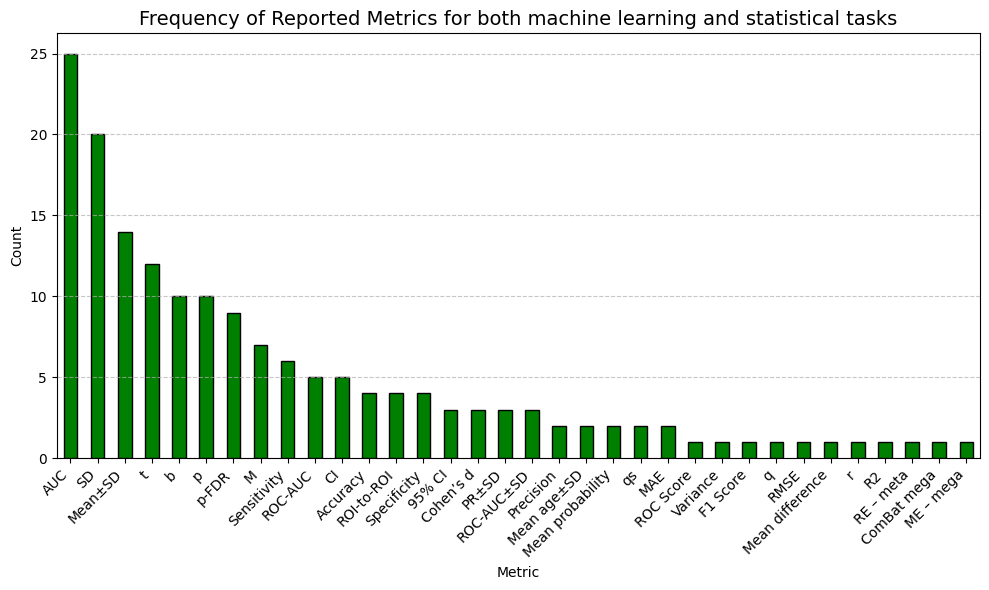

In [24]:
# Plotting
plt.figure(figsize=(10, 6))
metric_counts.plot(kind='bar', color='green', edgecolor='black')
plt.title("Frequency of Reported Metrics for both machine learning and statistical tasks", fontsize=14)
plt.xlabel("Metric")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show plot
# Save and display the figure
plt.savefig(root_dir+"metrics_count.png", dpi=1200, bbox_inches="tight")
plt.show()

In [25]:
# Clean: Drop rows where Metric is NaN
df_clean_papers = df.dropna(subset=["Papers3"])

In [26]:
df_clean_papers

,Papers,Metric,Performance,Category,Papers2,Papers3
0,Classification,Accuracy,98.4,Classification,Classification,Classification
1,NaN,Precision,98.82,Classification,NaN,Statistical
2,NaN,Sensitivity,96.44,Classification,NaN,Regression and Classification
3,NaN,F1 Score,97.67,Classification,NaN,Classification
4,NaN,ROC Score,99.87,Classification,NaN,Regression
5,Statistical,M,69.1,Statistical,NaN,Statistical and Regression
6,NaN,SD,18.9,Statistical,NaN,Statistical and Regression
7,NaN,M,89.4,Statistical,NaN,Classification
8,NaN,SD,15.3,Statistical,NaN,Statistical
9,NaN,t,-3.62,Statistical,NaN,Classification


In [27]:
# Count the frequency of each Metric
papers_counts = df_clean_papers["Papers3"].value_counts()



In [28]:
papers_counts

,count
Papers3,
Classification,9
Statistical,6
Regression and Classification,2
Statistical and Regression,2
Regression,1
Statistical and Segmentation,1
Statistical and Classification,1
Segmentation,1


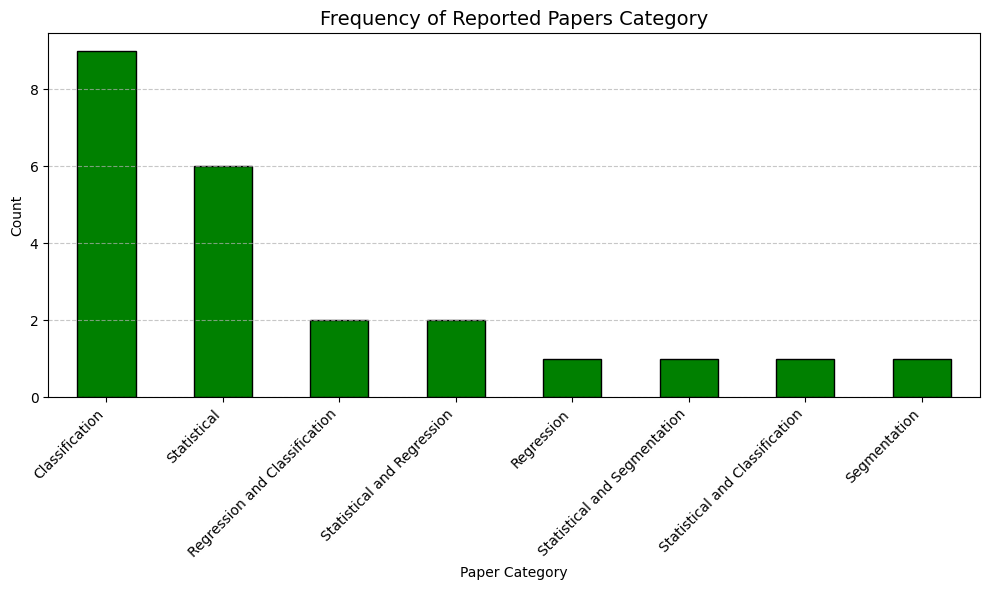

In [29]:
# Plotting
plt.figure(figsize=(10, 6))
papers_counts.plot(kind='bar', color='green', edgecolor='black')
plt.title("Frequency of Reported Papers Category", fontsize=14)
plt.xlabel("Paper Category")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show plot
# Save and display the figure
plt.savefig(root_dir+"papers_count.png", dpi=1200, bbox_inches="tight")
plt.show()

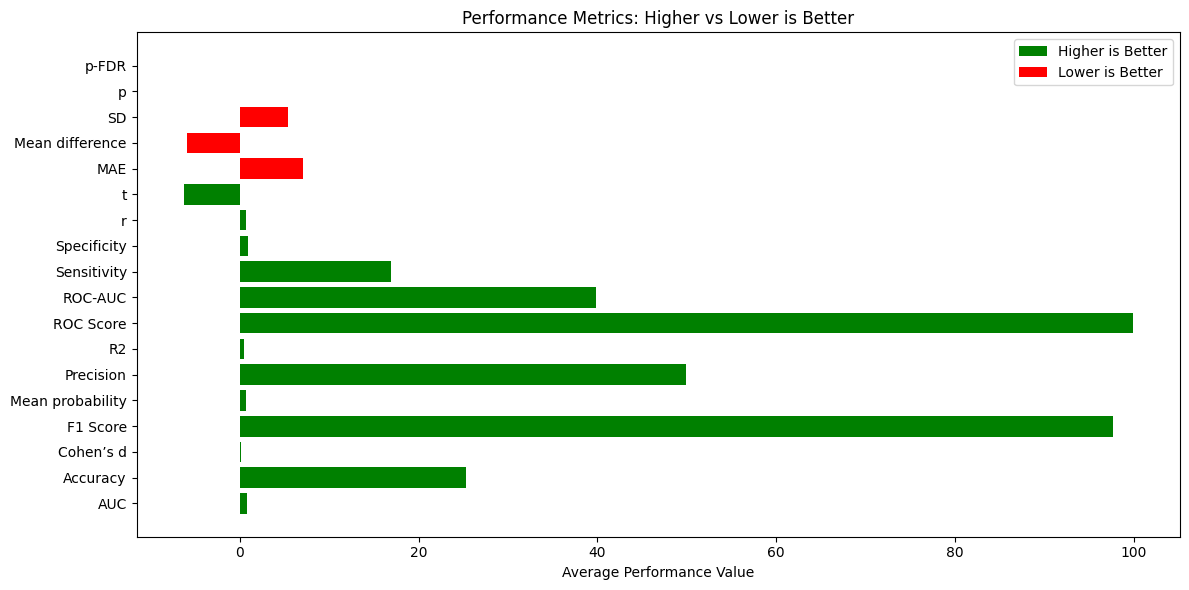

In [30]:
# Clean numeric values (if in format like "0.696±0.18" or have ±)
def extract_mean(value):
    if isinstance(value, str) and '±' in value:
        return float(value.split('±')[0])
    try:
        return float(value)
    except:
        return None

df['Cleaned_Performance'] = df['Performance'].apply(extract_mean)

# Categorize metrics
higher_better = [
    'Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC Score', 'AUC',
    'ROC-AUC', 'Specificity', 'Sensitivity', 'R2', 'Cohen’s d', 't', 'r', 'Mean probability'
]
lower_better = [
    'MAE', 'RMSE', 'SD', 'Variance', 'p', 'p-FDR', 'FDR correction', 'Mean difference'
]

# Group and compute mean performance for each metric
metric_perf = df.groupby('Metric')['Cleaned_Performance'].mean().dropna()

# Separate into two groups
high_better_vals = metric_perf[metric_perf.index.isin(higher_better)]
low_better_vals = metric_perf[metric_perf.index.isin(lower_better)]

# Plotting
plt.figure(figsize=(12, 6))
plt.barh(high_better_vals.index, high_better_vals.values, color='green', label='Higher is Better')
plt.barh(low_better_vals.index, low_better_vals.values, color='red', label='Lower is Better')
plt.xlabel('Average Performance Value')
plt.title('Performance Metrics: Higher vs Lower is Better')
plt.legend()
plt.tight_layout()
plt.show()

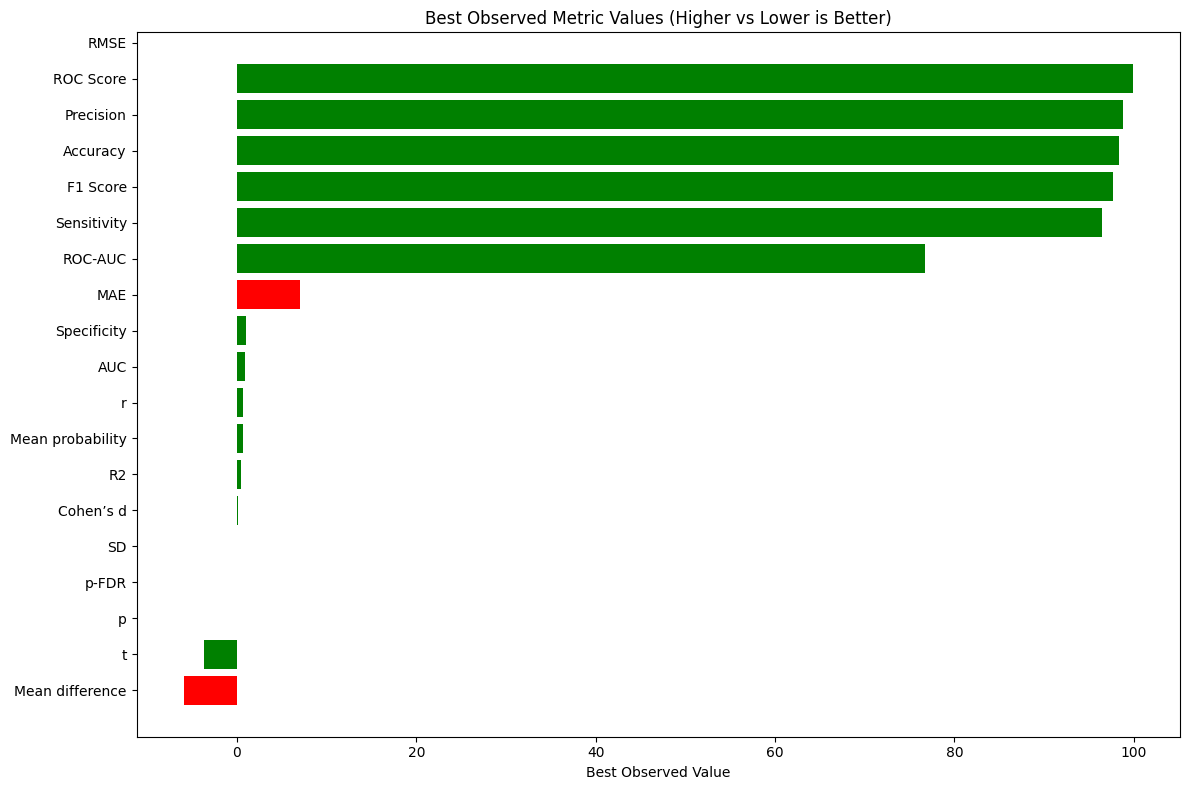

In [31]:
# Clean numeric values (extract mean if in "mean±SD" format)
def extract_numeric(value):
    if isinstance(value, str) and '±' in value:
        value = value.split('±')[0]
    try:
        return float(value)
    except:
        return None

df['Cleaned_Performance'] = df['Performance'].apply(extract_numeric)

# Define metric quality direction
higher_better = {
    'Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC Score', 'AUC',
    'ROC-AUC', 'Specificity', 'Sensitivity', 'R2', 'Cohen’s d', 't', 'r',
    'Mean probability'
}
lower_better = {
    'MAE', 'RMSE', 'SD', 'Variance', 'p', 'p-FDR', 'FDR correction', 'Mean difference'
}

# Get highest or lowest value for each metric depending on its type
metric_extremes = {}

for metric in df['Metric'].dropna().unique():
    sub_df = df[df['Metric'] == metric]
    values = sub_df['Cleaned_Performance'].dropna()

    if metric in higher_better:
        metric_extremes[metric] = values.max()
    elif metric in lower_better:
        metric_extremes[metric] = values.min()
    # Optional: include uncategorized metrics
    # else:
    #     metric_extremes[metric] = values.mean()

# Convert to DataFrame for plotting
result_df = pd.DataFrame.from_dict(metric_extremes, orient='index', columns=['Value'])
result_df = result_df.sort_values(by='Value')

# Assign colors based on metric direction
colors = ['green' if metric in higher_better else 'red' for metric in result_df.index]

# Plot
plt.figure(figsize=(12, 8))
plt.barh(result_df.index, result_df['Value'], color=colors)
plt.xlabel('Best Observed Value')
plt.title('Best Observed Metric Values (Higher vs Lower is Better)')
plt.tight_layout()
plt.show()

In [33]:
data

,Papers,Metric,Performance,Category,Papers2,Papers3
0,Classification,Accuracy,98.4,Classification,Classification,Classification
1,NaN,Precision,98.82,Classification,NaN,Statistical
2,NaN,Sensitivity,96.44,Classification,NaN,Regression and Classification
3,NaN,F1 Score,97.67,Classification,NaN,Classification
4,NaN,ROC Score,99.87,Classification,NaN,Regression
...,...,...,...,...,...,...
163,NaN,Mean±SD,0.696±0.18,Statistical,Segmentation,NaN
164,Statistical,M,69.1,Statistical,NaN,NaN
165,NaN,M,89.4,Statistical,NaN,NaN
166,NaN,SD,18.9,Statistical,NaN,NaN


In [37]:
data_extract = pd.DataFrame(data[['Metric','Performance','Category']])
data_extract

,Metric,Performance,Category
0,Accuracy,98.4,Classification
1,Precision,98.82,Classification
2,Sensitivity,96.44,Classification
3,F1 Score,97.67,Classification
4,ROC Score,99.87,Classification
...,...,...,...
163,Mean±SD,0.696±0.18,Statistical
164,M,69.1,Statistical
165,M,89.4,Statistical
166,SD,18.9,Statistical


In [42]:
# Clean performance column: convert to numeric, errors to NaN
data_extract['Performance'] = pd.to_numeric(df['Performance'], errors='coerce')

/tmp/ipython-input-561789388.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette="Set2")


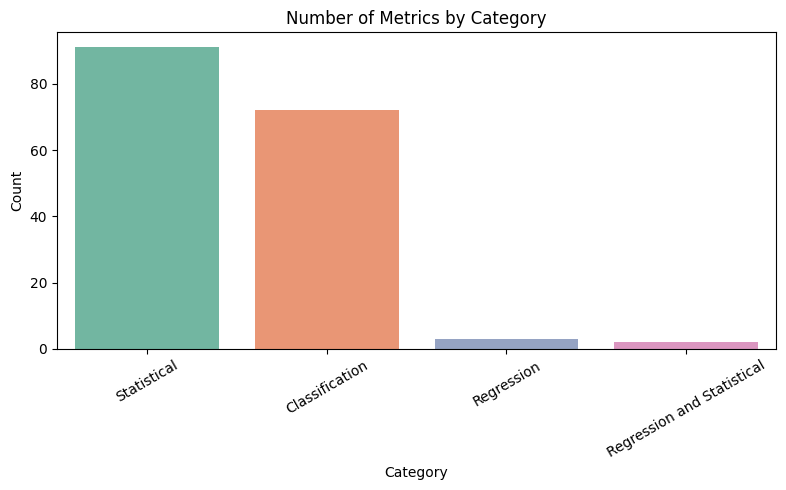

In [48]:
# ---- 1. Count of metrics by category ----
category_counts = df['Category'].value_counts()
plt.figure(figsize=(8,5))
sns.barplot(x=category_counts.index, y=category_counts.values, palette="Set2")
plt.title("Number of Metrics by Category")
plt.ylabel("Count")
plt.xlabel("Category")
plt.xticks(rotation=30)
plt.tight_layout()
# Show plot
# Save and display the figure
plt.savefig(root_dir+"metrics_category.png", dpi=1200, bbox_inches="tight")
plt.show()

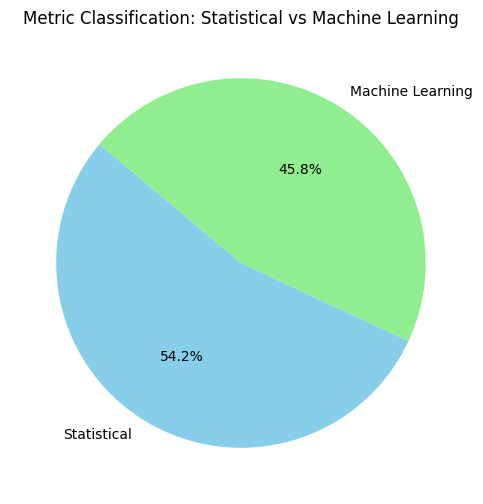

In [50]:
# ---- 3. Classification: Statistical vs Machine Learning ----
# Define Machine Learning/AI as Classification or Regression
df['Type'] = df['Category'].apply(lambda x: 'Machine Learning' if 'Classification' in x or 'Regression' in x else 'Statistical')
type_counts = df['Type'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%', colors=['skyblue','lightgreen'], startangle=140)
plt.title("Metric Classification: Statistical vs Machine Learning")
# Show plot
# Save and display the figure
plt.savefig(root_dir+"metrics_classification.png", dpi=1200, bbox_inches="tight")
plt.show()

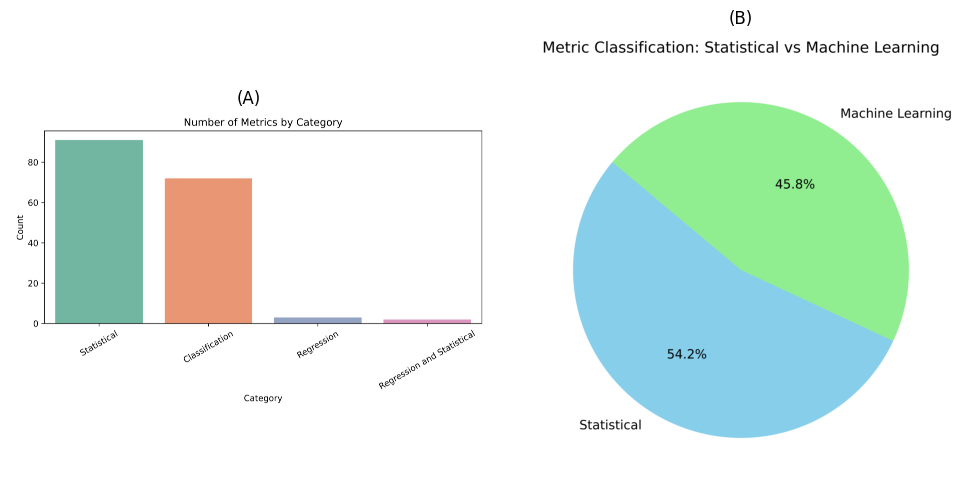

In [56]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Load images
a = mpimg.imread(root_dir+"metrics_category.png")
b = mpimg.imread(root_dir+"metrics_classification.png")

# Create a figure with 1 row, 2 columns (side by side)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Display image a
axes[0].imshow(a)
axes[0].set_title("(A)")
axes[0].axis('off')  # Hide axes

# Display image b
axes[1].imshow(b)
axes[1].set_title("(B)")
axes[1].axis('off')

# Adjust spacing
plt.tight_layout()

# Save and display the figure
plt.savefig(root_dir+"metrics_a_and_b.png", dpi=1200, bbox_inches="tight")
plt.show()